dataset

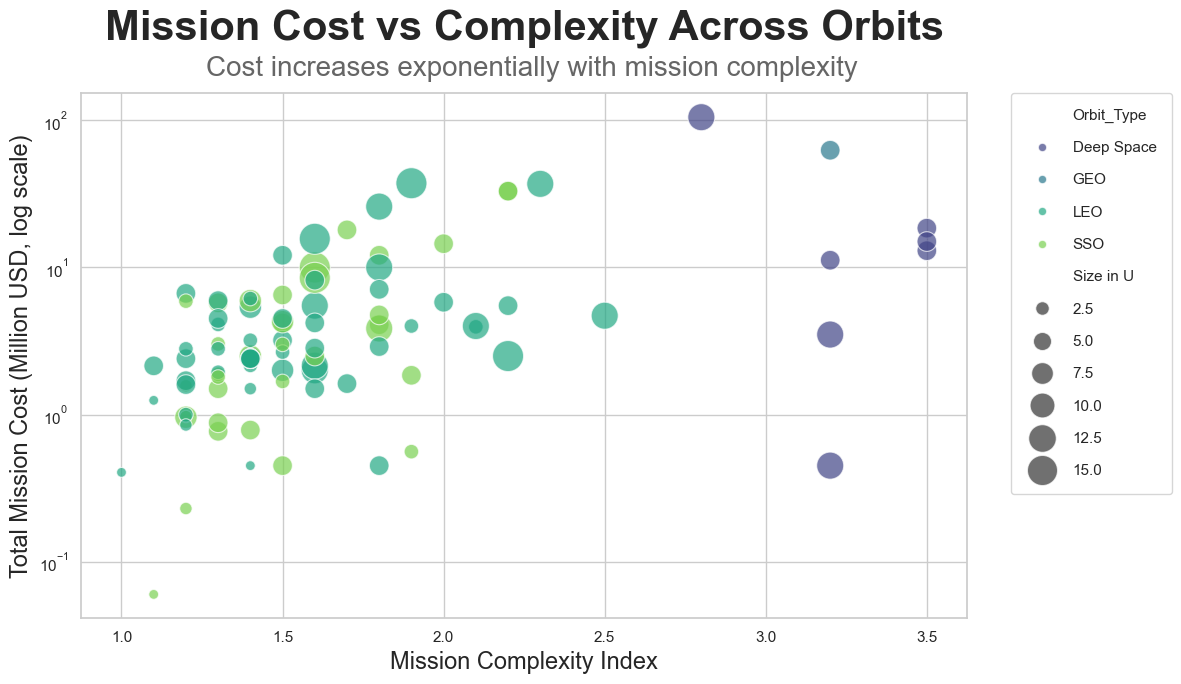

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION VISUELLE ---
# On choisit un style blanc et quadrillé, parfait pour l'impression sur poster
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET NETTOYAGE ---
file_path = "ESA_CNES - CubeSeat Dataset - data.csv"
df = pd.read_csv(file_path)

#df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes

# Nettoyage de la colonne Coût : on remplace la virgule par un point et on convertit en float
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)

# --- 4. SCATTER PLOT (LE PLAN KNN) ---
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='Complexity_Score', 
    y='Coût Total (USD)', 
    hue='Orbit_Type', 
    size='Size in U', 
    sizes=(50, 500), 
    alpha=0.7,
    palette="viridis"
)


plt.yscale('log') # Échelle log car les coûts varient de 0.06 à 105M$
plt.title("Mission Cost vs Complexity Across Orbits\n", fontsize=30, fontweight='bold', ha='center')
#plt.title("Cost increases exponentially with mission complexity", fontsize=20, fontweight='normal', ha='center')
plt.gcf().text(0.45, 0.88, "Cost increases exponentially with mission complexity", ha='center', fontsize=20,
            color='#666', fontweight='normal')
plt.xlabel("Mission Complexity Index", fontsize=17)
plt.ylabel("Total Mission Cost (Million USD, log scale)", fontsize=17)
plt.legend(bbox_to_anchor=(1.05, 1), 
            loc='upper left',
            borderaxespad=0.,
            labelspacing=1.2,
            handletextpad=1.0,
            borderpad=1.0
            )
plt.tight_layout()
plt.show()


Model

In [5]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")

# On centre l'année pour aider le modèle à converger (2024 = 0)
df['Year_Scaled'] = df['Année (Launch)'] - 2024
# Avant de définir ton modèle, fusionne les catégories dans ton dataframe
df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes
# Suppression de la ligne vide si nécessaire
df = df.dropna(subset=['Coût Total (USD)'])

n_orbits = len(orbit_names)
# 2. Construction du Modèle Bayésien
with pm.Model() as cubesat_model:
    # --- Priors (nos hypothèses de départ) ---
    alpha_orbit = pm.Normal("alpha_orbit", mu=0, sigma=1.5, shape=n_orbits)
    beta_size = pm.Normal("beta_size", mu=0.5, sigma=1)
    beta_complexity = pm.Normal("beta_complexity", mu=1, sigma=1) # On s'attend à un effet fort
    beta_comm = pm.Normal("beta_comm", mu=0, sigma=1)
    beta_year = pm.Normal("beta_year", mu=0, sigma=1)
    
    sigma = pm.HalfNormal("sigma", sigma=1) # Incertitude du modèle
    
    # --- Équation de la moyenne (Log-Link) ---
    mu = (alpha_orbit[df.orbit_idx.values] + 
          beta_size * df['Size in U'].values + 
          beta_complexity * df['Complexity_Score'].values +
          beta_comm * df['Is_Commercial'].values + 
          beta_year * df['Year_Scaled'].values)
    
    # --- Likelihood (La loi Log-Normale) ---
    y_obs = pm.LogNormal("y_obs", mu=mu, sigma=sigma, observed=df['Coût Total (USD)'].values)
    
    # --- Inférence (Le modèle "apprend") ---
    trace = pm.sample(2000, tune=1000, target_accept=0.95)

# 3. Visualisation des résultats


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_orbit, beta_size, beta_complexity, beta_comm, beta_year, sigma]


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 82 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_orbit[0]  -1.030  0.867  -2.665    0.586      0.021    0.014    1652.0   
alpha_orbit[1]  -0.589  0.445  -1.438    0.238      0.011    0.007    1569.0   
alpha_orbit[2]  -0.672  0.459  -1.588    0.156      0.012    0.007    1570.0   
beta_size        0.081  0.033   0.019    0.140      0.001    0.001    3250.0   
beta_complexity  0.913  0.277   0.388    1.424      0.007    0.004    1738.0   
beta_comm       -0.133  0.219  -0.540    0.280      0.004    0.004    3405.0   
beta_year        0.046  0.043  -0.035    0.127      0.001    0.001    3125.0   
sigma            1.022  0.075   0.894    1.164      0.001    0.002    3418.0   

                 ess_tail  r_hat  
alpha_orbit[0]     2375.0    1.0  
alpha_orbit[1]     2144.0    1.0  
alpha_orbit[2]     2209.0    1.0  
beta_size          2538.0    1.0  
beta_complexity    2287.0    1.0  
beta_comm          2327.0    1.0  
beta_year          2185.0    1.0  

<Figure size 1000x600 with 0 Axes>

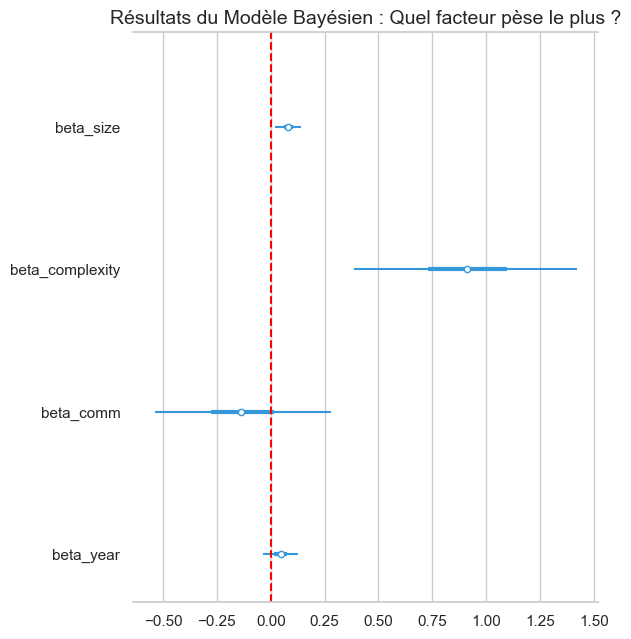

In [6]:
print(az.summary(trace))
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_complexity", "beta_comm", "beta_year"], combined=True, colors="#3498db")
plt.axvline(0, color='red', linestyle='--')
plt.title("Résultats du Modèle Bayésien : Quel facteur pèse le plus ?", fontsize=14)
plt.show()

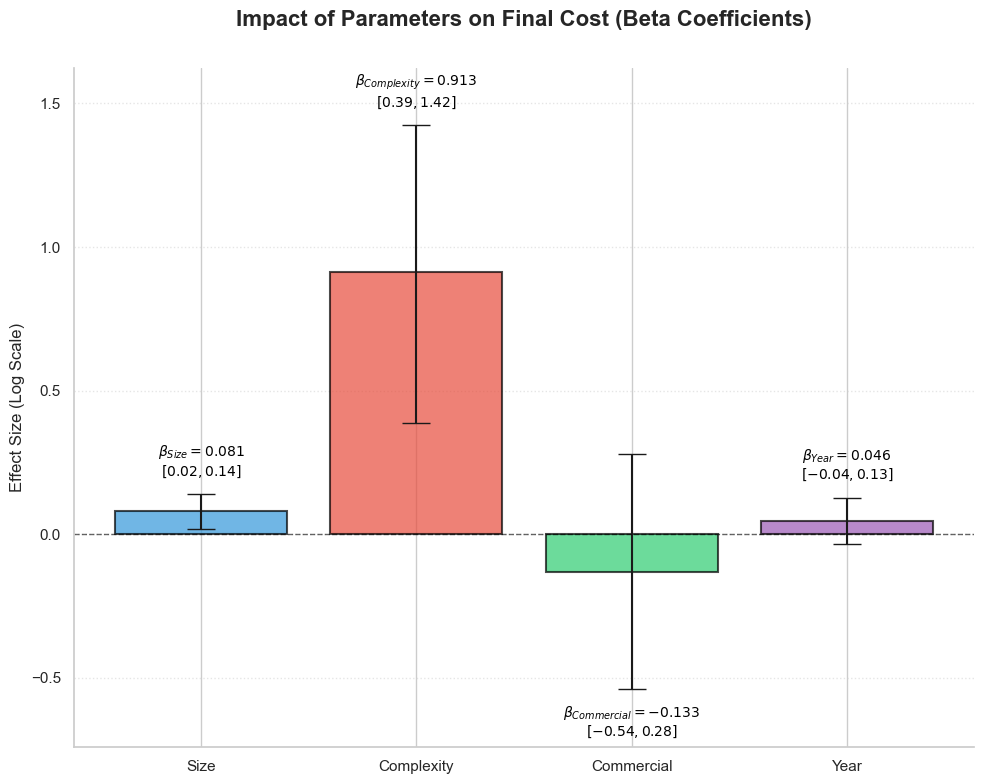

In [22]:
import matplotlib.pyplot as plt

# Données
labels = ["Size", "Complexity", "Commercial", "Year"]
means = [0.081, 0.913, -0.133, 0.046]
hdi_low = [0.019, 0.388, -0.540, -0.035]
hdi_high = [0.140, 1.424, 0.280, 0.127]

# Calcul des erreurs
yerr_down = [m - l for m, l in zip(means, hdi_low)]
yerr_up = [h - m for m, h in zip(means, hdi_high)]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = ax.bar(labels, means, yerr=[yerr_down, yerr_up], 
              color=colors, alpha=0.7, capsize=10, 
              edgecolor='black', linewidth=1.5)

# --- SOLUTION POUR LES COLLISIONS ---
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Texte du label avec moyenne et crochets HDI
    label_text = fr"$\beta_{{{labels[i]}}} = {means[i]:.3f}$" + "\n" + fr"$[{hdi_low[i]:.2f}, {hdi_high[i]:.2f}]$"
    
    if height >= 0:
        # Pour les barres positives : au-dessus de la moustache haute
        y_pos = hdi_high[i] + 0.05
        va = 'bottom'
    else:
        # Pour les barres négatives : en-dessous de la moustache basse
        # On descend assez pour ne pas toucher le nom "Commercial"
        y_pos = hdi_low[i] - 0.05
        va = 'top'
    
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label_text, 
            ha='center', va=va, fontweight='bold', fontsize=10, color='black')

# Ligne de neutralité
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)

# Ajustement des limites pour que le texte ne sorte pas du cadre
ax.set_ylim(min(hdi_low) - 0.2, max(hdi_high) + 0.2)

# Cosmétique
ax.set_title("Impact of Parameters on Final Cost (Beta Coefficients)", 
             fontsize=16, fontweight='bold', pad=30)
ax.set_ylabel("Effect Size (Log Scale)", fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()